# SRResNet – Super-Resolution + Segmentation on ISPRS Potsdam
**Architecture:** SRResNet with residual blocks + ASPP segmentation head  
**Dataset:** ISPRS Potsdam (6 classes) | flat patches folder | **Scale:** 4×

---


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "torch", "torchvision", "opencv-python",
                       "scikit-image", "matplotlib", "tqdm", "--quiet"])
print(" Dependencies ready")

 Dependencies ready


In [2]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
ROOT    = r"C:\Users\Azozi\Desktop\patches"   # Path to dataset root
IMG_DIR = os.path.join(ROOT, "Images")
LBL_DIR = os.path.join(ROOT, "Labels")

BEST_MODEL_PATH = "best_model_potsdam.pth"

# Hyper-parameters
NUM_CLASSES                 = 6
SCALE                       = 4
EPOCHS                      = 50
BATCH                       = 4    
GRADIENT_ACCUMULATION_STEPS = 4    
LR                          = 2e-4
NUM_RES_BLOCKS              = 16   # SRResNet depth

VALID_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')

CLASS_COLORS = [
    [255, 255, 255],  # 0 Impervious (White)
    [  0,   0, 255],  # 1 Building   (Blue)
    [  0, 255, 255],  # 2 Low Veg    (Cyan)
    [  0, 255,   0],  # 3 Tree       (Green)
    [255, 255,   0],  # 4 Car        (Yellow)
    [255,   0,   0],  # 5 Clutter    (Red)
]
CLASS_NAMES = ["Impervious surfaces", "Building", "Low vegetation",
               "Tree", "Car", "Clutter/Background"]

CLASS_WEIGHTS = torch.tensor([1.0, 1.0, 1.5, 1.5, 6.0, 2.5], dtype=torch.float32)
print(" Configuration set")


 Configuration set


In [ ]:
def _sorted_pairs(img_dir, lbl_dir):

    def _key(f):
        base = os.path.splitext(f)[0]
        parts = base.split("_")
        try:
            return int(parts[-1])
        except ValueError:
            return base

    imgs = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(VALID_EXTS)], key=_key)
    pairs = []
    for img_name in imgs:
        stem  = os.path.splitext(img_name)[0]          
        num   = stem.split("_")[-1]                     
        found = None
        for ext in VALID_EXTS:
            for prefix in ["Label", "label", "LABEL", "mask", "Mask"]:
                candidate = os.path.join(lbl_dir, f"{prefix}_{num}{ext}")
                if os.path.exists(candidate):
                    found = candidate
                    break
            if found:
                break
        # Exact same filename fallback
        if found is None:
            exact = os.path.join(lbl_dir, img_name)
            if os.path.exists(exact):
                found = exact
        if found is None:
            print(f"  No label found for {img_name}, skipping")
            continue
        pairs.append((os.path.join(img_dir, img_name), found))
    return pairs


ALL_PAIRS = _sorted_pairs(IMG_DIR, LBL_DIR)
print(f"Total paired patches: {len(ALL_PAIRS)}")
if len(ALL_PAIRS) == 0:
    raise ValueError(
        f" No pairs found!\n"
        f"  IMG_DIR = {IMG_DIR}\n"
        f"  LBL_DIR = {LBL_DIR}\n"
        f"  Check that both folders exist and files share a numeric suffix."
    )

# Deterministic 70 / 20 / 10 split
np.random.seed(42)
idx   = np.random.permutation(len(ALL_PAIRS))
n     = len(ALL_PAIRS)
t_end = int(n * 0.70)
v_end = int(n * 0.90)

TRAIN_PAIRS = [ALL_PAIRS[i] for i in idx[:t_end]]
VAL_PAIRS   = [ALL_PAIRS[i] for i in idx[t_end:v_end]]
TEST_PAIRS  = [ALL_PAIRS[i] for i in idx[v_end:]]
print(f"Train: {len(TRAIN_PAIRS)} | Val: {len(VAL_PAIRS)} | Test: {len(TEST_PAIRS)}")


def parse_mask(mask_path):

    raw = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if raw is None:
        raise FileNotFoundError(f"Cannot read mask: {mask_path}")
    if len(raw.shape) == 3:
        rgb  = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        mask = np.full(rgb.shape[:2], 5, dtype=np.int64)
        for ci, color in enumerate(CLASS_COLORS):
            mask[np.all(rgb == color, axis=-1)] = ci
    else:
        mask = raw.astype(np.int64)
        mask[(mask < 0) | (mask >= NUM_CLASSES)] = 5
    return mask


class PotsdamDataset(Dataset):

    def __init__(self, pairs, scale_factor=4, augment=False):
        self.pairs, self.scale, self.augment = pairs, scale_factor, augment
        self.to_t = T.ToTensor()

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        hr = cv2.imread(img_path)
        if hr is None:
            raise FileNotFoundError(f"Cannot read image: {img_path}")
        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

        h, w = hr.shape[:2]
        lr   = cv2.resize(hr, (w // self.scale, h // self.scale),
                          interpolation=cv2.INTER_CUBIC)
        mask = parse_mask(mask_path)

        if self.augment:
            if np.random.rand() > 0.5:
                hr, lr, mask = np.fliplr(hr).copy(), np.fliplr(lr).copy(), np.fliplr(mask).copy()
            if np.random.rand() > 0.5:
                hr, lr, mask = np.flipud(hr).copy(), np.flipud(lr).copy(), np.flipud(mask).copy()
            k = np.random.randint(4)
            if k > 0:
                hr   = np.rot90(hr,   k).copy()
                lr   = np.rot90(lr,   k).copy()
                mask = np.rot90(mask, k).copy()

        return self.to_t(lr), self.to_t(hr), torch.from_numpy(mask)


def get_train_dataset(): return PotsdamDataset(TRAIN_PAIRS, SCALE, augment=True)
def get_val_dataset():   return PotsdamDataset(VAL_PAIRS,   SCALE, augment=False)
def get_test_dataset():  return PotsdamDataset(TEST_PAIRS,  SCALE, augment=False)
print(" Dataset ready")


Total paired patches: 2400
Train: 1680 | Val: 480 | Test: 240
 Dataset ready


In [ ]:
class ASPP(nn.Module):

    def __init__(self, ch):
        super().__init__()
        self.b1   = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1,  dilation=1), nn.ReLU(True))
        self.b2   = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=2,  dilation=2), nn.ReLU(True))
        self.b4   = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=4,  dilation=4), nn.ReLU(True))
        self.fuse = nn.Conv2d(ch * 3, ch, 1)

    def forward(self, x):
        return self.fuse(torch.cat([self.b1(x), self.b2(x), self.b4(x)], dim=1))


class ResBlock(nn.Module):

    def __init__(self, feat):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(feat, feat, 3, padding=1, bias=False),
            nn.BatchNorm2d(feat),
            nn.PReLU(),
            nn.Conv2d(feat, feat, 3, padding=1, bias=False),
            nn.BatchNorm2d(feat),
        )

    def forward(self, x):
        return x + self.block(x)


class UpsampleBlock(nn.Module):

    def __init__(self, feat):
        super().__init__()
        self.conv = nn.Conv2d(feat, feat * 4, 3, padding=1)
        self.ps   = nn.PixelShuffle(2)
        self.act  = nn.PReLU()

    def forward(self, x):
        return self.act(self.ps(self.conv(x)))


class SRResNetSeg(nn.Module):

    def __init__(self, scale_factor=4, num_classes=6, feat=64, num_res_blocks=16):
        super().__init__()
        assert scale_factor == 4, "This implementation uses two 2× stages → scale must be 4"
        self.scale = scale_factor

        # Head
        self.head = nn.Sequential(
            nn.Conv2d(3, feat, 9, padding=4),
            nn.PReLU(),
        )

        # Residual body
        self.body = nn.Sequential(*[ResBlock(feat) for _ in range(num_res_blocks)])
        self.body_tail = nn.Sequential(
            nn.Conv2d(feat, feat, 3, padding=1, bias=False),
            nn.BatchNorm2d(feat),
        )

        # ASPP at LR resolution
        self.aspp = ASPP(feat)

        # Two 2× upsampling stages → 4× total
        self.up1 = UpsampleBlock(feat)
        self.up2 = UpsampleBlock(feat)

        # SR reconstruction
        self.recon = nn.Conv2d(feat, 3, 9, padding=4)

        # Segmentation head
        self.seg_head = nn.Sequential(
            nn.Conv2d(feat, 32, 1), nn.ReLU(True),
            nn.Conv2d(32,  32,  3, padding=1), nn.ReLU(True),
            nn.Conv2d(32, num_classes, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x - 0.5

        # Feature extraction with global residual
        head_feat = self.head(x)                          # LR features
        body_feat = self.body_tail(self.body(head_feat))  # residual body
        lr_feat   = self.aspp(head_feat + body_feat)      # ASPP + global skip

        # Upsampling → HR feature space
        hr_feat = self.up2(self.up1(lr_feat))             # 4× HR features

        # Segmentation with attention
        seg_map   = self.seg_head(hr_feat)
        attention = torch.softmax(seg_map, dim=1).max(dim=1, keepdim=True)[0]
        hr_feat   = hr_feat * (1.0 + attention)

        # SR output
        sr = self.recon(hr_feat) + 0.5
        return sr, seg_map


# Sanity check
_m = SRResNetSeg(SCALE, NUM_CLASSES, num_res_blocks=NUM_RES_BLOCKS)
_sr, _seg = _m(torch.randn(1, 3, 64, 64))
print(f" SRResNetSeg  SR: {tuple(_sr.shape)}  Seg: {tuple(_seg.shape)}")
print(f"   Parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _sr, _seg

 SRResNetSeg  SR: (1, 3, 256, 256)  Seg: (1, 6, 256, 256)
   Parameters: 1,682,012


In [7]:
l1_loss = nn.L1Loss()

def edge_loss(sr, hr):
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32,
                       device=sr.device).view(1,1,3,3)
    ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32,
                       device=sr.device).view(1,1,3,3)
    sg, hg = sr.mean(1, keepdim=True), hr.mean(1, keepdim=True)
    se = torch.abs(F.conv2d(sg, kx, padding=1)) + torch.abs(F.conv2d(sg, ky, padding=1))
    he = torch.abs(F.conv2d(hg, kx, padding=1)) + torch.abs(F.conv2d(hg, ky, padding=1))
    return F.l1_loss(se, he)

def dice_loss(pred_logits, target, num_classes=NUM_CLASSES, eps=1e-6):
    ps = torch.softmax(pred_logits, dim=1)
    oh = F.one_hot(target, num_classes).permute(0,3,1,2).float()
    inter = (ps * oh).sum(dim=(2,3))
    card  = ps.sum(dim=(2,3)) + oh.sum(dim=(2,3))
    return (1.0 - (2.0*inter+eps)/(card+eps)).mean()

def focal_loss(pred_logits, target, cw, gamma=2.0):
    ce    = F.cross_entropy(pred_logits, target, weight=cw, reduction='none')
    focal = ((1 - torch.exp(-ce))**gamma) * ce
    return focal.mean()

def seg_loss(pred_logits, target, ce_fn, cw):
    return (0.4*ce_fn(pred_logits, target)
          + 0.4*dice_loss(pred_logits, target)
          + 0.2*focal_loss(pred_logits, target, cw))

print(" Loss functions defined")

 Loss functions defined


In [ ]:
def train():
    train_ds = get_train_dataset()
    val_ds   = get_val_dataset()

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                              num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False,
                              num_workers=0, pin_memory=False)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

    model     = SRResNetSeg(SCALE, NUM_CLASSES, num_res_blocks=NUM_RES_BLOCKS).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    scaler    = torch.amp.GradScaler('cuda')

    ce_fn = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE))
    cw    = CLASS_WEIGHTS.to(DEVICE)

    best_psnr, train_losses = 0.0, []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        optimizer.zero_grad()

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:3d}/{EPOCHS}", leave=True)
        for i, (lr_b, hr_b, mask_b) in enumerate(pbar):
            lr_b, hr_b, mask_b = lr_b.to(DEVICE), hr_b.to(DEVICE), mask_b.to(DEVICE)

            with torch.amp.autocast('cuda'):
                sr_b, seg_map = model(lr_b)

                # Align spatial dims in case of odd sizes (crop center of HR to match SR)
                hs, ws = sr_b.shape[2:]
                hh, wh = hr_b.shape[2:]
                t, l   = (hh-hs)//2, (wh-ws)//2
                hr_c   = hr_b[:, :, t:t+hs, l:l+ws]

                loss = (0.40 * l1_loss(sr_b, hr_c)
                      + 0.45 * seg_loss(seg_map, mask_b, ce_fn, cw)
                      + 0.15 * edge_loss(sr_b, hr_c)
                       ) / GRADIENT_ACCUMULATION_STEPS

            scaler.scale(loss).backward()

            if (i+1) % GRADIENT_ACCUMULATION_STEPS == 0 or (i+1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad()

            epoch_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
            pbar.set_postfix({"loss": f"{loss.item()*GRADIENT_ACCUMULATION_STEPS:.4f}"})

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        scheduler.step()

        if (epoch+1) % 5 == 0 or epoch == EPOCHS-1:
            model.eval(); psnrs = []
            with torch.no_grad():
                for lr_b, hr_b, _ in tqdm(val_loader, desc="  Validating"):
                    sr_b, _ = model(lr_b.to(DEVICE))
                    for j in range(sr_b.shape[0]):
                        sr_i = np.clip(sr_b[j].cpu().numpy().transpose(1,2,0), 0, 1)
                        hr_i = np.clip(hr_b[j].cpu().numpy().transpose(1,2,0), 0, 1)
                        psnrs.append(psnr_fn(hr_i, sr_i, data_range=1.0))
            avg_psnr = np.mean(psnrs)
            tqdm.write(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val PSNR: {avg_psnr:.2f} dB")
            if avg_psnr > best_psnr:
                best_psnr = avg_psnr
                torch.save(model.state_dict(), BEST_MODEL_PATH)
                tqdm.write(f"  >>> SAVED BEST: {best_psnr:.2f} dB → {BEST_MODEL_PATH}")
        else:
            tqdm.write(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f}")

    return model, train_losses


model, train_losses = train()

Train: 1680 | Val: 480


Epoch   1/50: 100%|██████████| 420/420 [00:29<00:00, 14.36it/s, loss=0.6619]


Epoch   1 | Loss: 0.8655


Epoch   2/50: 100%|██████████| 420/420 [00:29<00:00, 14.06it/s, loss=0.5846]


Epoch   2 | Loss: 0.6099


...

Epoch  48 | Loss: 0.4053


Epoch  49/50: 100%|██████████| 420/420 [00:27<00:00, 15.39it/s, loss=0.7278]


Epoch  49 | Loss: 0.4053


  Validating: 100%|██████████| 240/240 [00:06<00:00, 36.17it/s]

Epoch  50 | Loss: 0.4066 | Val PSNR: 23.63 dB


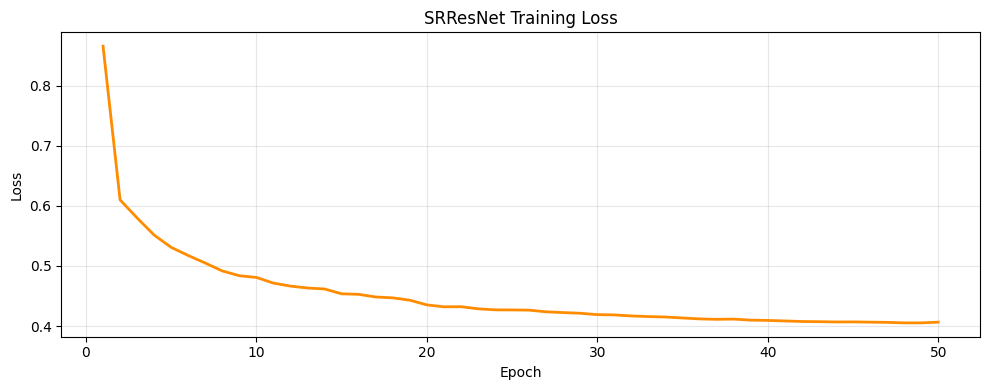

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, color='darkorange', linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("SRResNet Training Loss")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [10]:
def classmap_to_color(class_map):
    color = np.zeros((*class_map.shape, 3), dtype=np.uint8)
    for ci, rgb in enumerate(CLASS_COLORS):
        color[class_map == ci] = rgb
    return color

def make_legend():
    return [mpatches.Patch(color=[c/255 for c in rgb], label=name)
            for name, rgb in zip(CLASS_NAMES, CLASS_COLORS)]

def evaluate(model, val_loader):
    model.eval()
    psnr_list, ssim_list = [], []
    conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    with torch.no_grad():
        for lr_b, hr_b, mask_b in tqdm(val_loader, desc="Evaluating"):
            sr_b, seg_map = model(lr_b.to(DEVICE))
            sr_np = np.clip(sr_b.squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
            hr_np = np.clip(hr_b.squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
            psnr_list.append(psnr_fn(hr_np, sr_np, data_range=1.0))
            ssim_list.append(ssim_fn(hr_np, sr_np, channel_axis=2, data_range=1.0))
            pred = seg_map.argmax(1).squeeze().cpu().numpy().flatten()
            gt   = mask_b.squeeze().numpy().flatten()
            conf += np.bincount(gt*NUM_CLASSES+pred,
                                minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)

    tp, eps = np.diag(conf), 1e-15
    fp  = conf.sum(0) - tp
    fn  = conf.sum(1) - tp
    prec = tp/(tp+fp+eps); rec = tp/(tp+fn+eps)
    f1   = 2*prec*rec/(prec+rec+eps)
    return {"psnr": np.mean(psnr_list), "ssim": np.mean(ssim_list),
            "accuracy": tp.sum()/conf.sum(),
            "f1": f1.mean(), "f1_per_class": f1}

def print_results(r):
    print("\n" + "="*52)
    print("    EVALUATION METRICS  (SRResNet + Potsdam)")
    print("="*52)
    print(f"  PSNR     : {r['psnr']:.2f} dB")
    print(f"  SSIM     : {r['ssim']:.4f}")
    print(f"  Accuracy : {r['accuracy']:.4f}")
    print(f"  Macro F1 : {r['f1']:.4f}")
    print("\n    PER-CLASS F1 SCORES")
    print("="*52)
    for name, score in zip(CLASS_NAMES, r['f1_per_class']):
        print(f"  {name:22s}: {score:.4f}  {'#'*int(score*20)}")
    print("="*52)

In [11]:
# Load best checkpoint
eval_model = SRResNetSeg(SCALE, NUM_CLASSES, num_res_blocks=NUM_RES_BLOCKS).to(DEVICE)
if os.path.exists(BEST_MODEL_PATH):
    eval_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
    print(f" Loaded: {BEST_MODEL_PATH}")
else:
    print(" No checkpoint — using random init")

val_loader_eval = DataLoader(get_val_dataset(), batch_size=1, shuffle=False, num_workers=0)
results = evaluate(eval_model, val_loader_eval)
print_results(results)

 Loaded: best_model_potsdam.pth


Evaluating: 100%|██████████| 480/480 [00:10<00:00, 45.34it/s]


    EVALUATION METRICS  (SRResNet + Potsdam)
  PSNR     : 23.77 dB
  SSIM     : 0.3966
  Accuracy : 0.6477
  Macro F1 : 0.5994

    PER-CLASS F1 SCORES
  Impervious surfaces   : 0.7258  ##############
  Building              : 0.6876  #############
  Low vegetation        : 0.6500  ############
  Tree                  : 0.4753  #########
  Car                   : 0.5475  ##########
  Clutter/Background    : 0.5099  ##########


>>> Saved: sresnet_val_sample.png


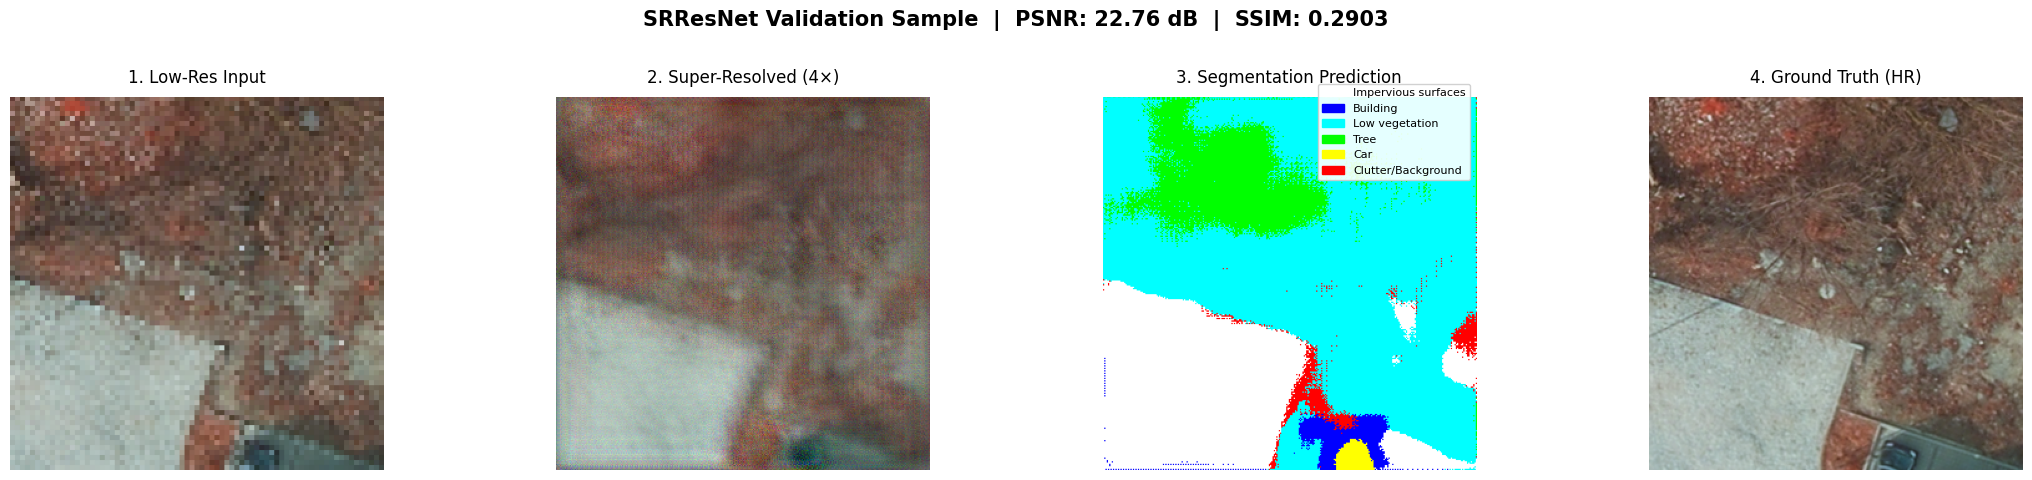

In [12]:
def visualize_sample(model, loader, title="Validation"):
    model.eval()
    lr_b, hr_b, mask_b = next(iter(loader))

    with torch.no_grad():
        sr_b, seg_map = model(lr_b.to(DEVICE))

    lr_np = cv2.resize(lr_b.squeeze().permute(1,2,0).numpy(),
                       (hr_b.size(3), hr_b.size(2)), interpolation=cv2.INTER_NEAREST)
    sr_np = np.clip(sr_b.squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
    hr_np = np.clip(hr_b.squeeze().permute(1,2,0).numpy(), 0, 1)
    seg_c = classmap_to_color(seg_map.argmax(1).squeeze().cpu().numpy())
    cur_p = psnr_fn(hr_np, sr_np, data_range=1.0)
    cur_s = ssim_fn(hr_np, sr_np, channel_axis=2, data_range=1.0)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), facecolor='white')
    plt.suptitle(f"SRResNet {title} Sample  |  PSNR: {cur_p:.2f} dB  |  SSIM: {cur_s:.4f}",
                 fontsize=15, fontweight='bold')
    for ax, (img, t) in zip(axes, [
        (lr_np, "1. Low-Res Input"),
        (sr_np, "2. Super-Resolved (4×)"),
        (seg_c, "3. Segmentation Prediction"),
        (hr_np, "4. Ground Truth (HR)"),
    ]):
        ax.imshow(img); ax.set_title(t, fontsize=12, pad=10); ax.axis('off')
    axes[2].legend(handles=make_legend(), loc='upper right',
                   bbox_to_anchor=(1.0,1.05), fontsize=8, framealpha=0.9)
    plt.tight_layout(rect=[0,0.03,1,0.95])
    plt.savefig("sresnet_val_sample.png", dpi=150, bbox_inches='tight')
    print(">>> Saved: sresnet_val_sample.png")
    plt.show()


visualize_sample(eval_model, val_loader_eval)

In [ ]:
def run_test_inference(model, save_dir="test_outputs", n_vis=8):
    os.makedirs(save_dir, exist_ok=True)

    test_loader = DataLoader(
        get_test_dataset(),
        batch_size=1,
        shuffle=False,
        num_workers=0
    )

    model.eval()
    print(f"Running inference on {len(test_loader)} test images...")

    psnr_list, ssim_list = [], []

    vis_count = 0

    with torch.no_grad():
        for idx, batch in enumerate(tqdm(test_loader, desc="Test inference")):

            lr_b, hr_b, mask_b = batch  

            lr_b = lr_b.to(DEVICE)
            hr_b = hr_b.to(DEVICE)

            sr_b, seg_b = model(lr_b)

            sr_np = np.clip(
                sr_b.squeeze().permute(1, 2, 0).cpu().numpy(),
                0, 1
            )

            hr_np = np.clip(
                hr_b.squeeze().permute(1, 2, 0).cpu().numpy(),
                0, 1
            )

            if seg_b.shape[2:] != mask_b.shape[1:]:
                seg_b = F.interpolate(
                    seg_b,
                    size=mask_b.shape[1:],
                    mode="bilinear",
                    align_corners=False
                )

            pred_mask = seg_b.argmax(1).squeeze().cpu().numpy()
            seg_c = classmap_to_color(pred_mask)

            gt_c = classmap_to_color(mask_b.squeeze().cpu().numpy())

            lr_np = cv2.resize(
                lr_b.squeeze().permute(1, 2, 0).cpu().numpy(),
                (hr_b.size(3), hr_b.size(2)),
                interpolation=cv2.INTER_NEAREST
            )

            psnr_list.append(psnr_fn(hr_np, sr_np, data_range=1.0))
            ssim_list.append(ssim_fn(hr_np, sr_np, channel_axis=2, data_range=1.0))

            if vis_count < n_vis:

                fig, axes = plt.subplots(1, 4, figsize=(20, 5))

                p = psnr_list[-1]
                s = ssim_list[-1]

                images = [
                    (lr_np, "LR Input"),
                    (sr_np, f"SR | PSNR={p:.2f} SSIM={s:.3f}"),
                    (seg_c, "Prediction"),
                    (gt_c, "Ground Truth"),
                ]

                for ax, (img, title) in zip(axes, images):
                    ax.imshow(img)
                    ax.set_title(title)
                    ax.axis("off")

                axes[2].legend(
                    handles=make_legend(),
                    loc="upper right",
                    fontsize=6,
                    framealpha=0.9
                )

                plt.tight_layout()

                save_path = os.path.join(save_dir, f"sample_{idx}.png")
                plt.savefig(save_path, dpi=120, bbox_inches="tight")
                plt.show()

                print(f"Saved: {save_path}")

                vis_count += 1

    print("\nDONE")
    print(f"Avg PSNR: {np.mean(psnr_list):.2f}")
    print(f"Avg SSIM: {np.mean(ssim_list):.4f}")

Evaluating: 100%|██████████| 480/480 [00:10<00:00, 44.49it/s]


>>> Saved: sresnet_val_sample.png


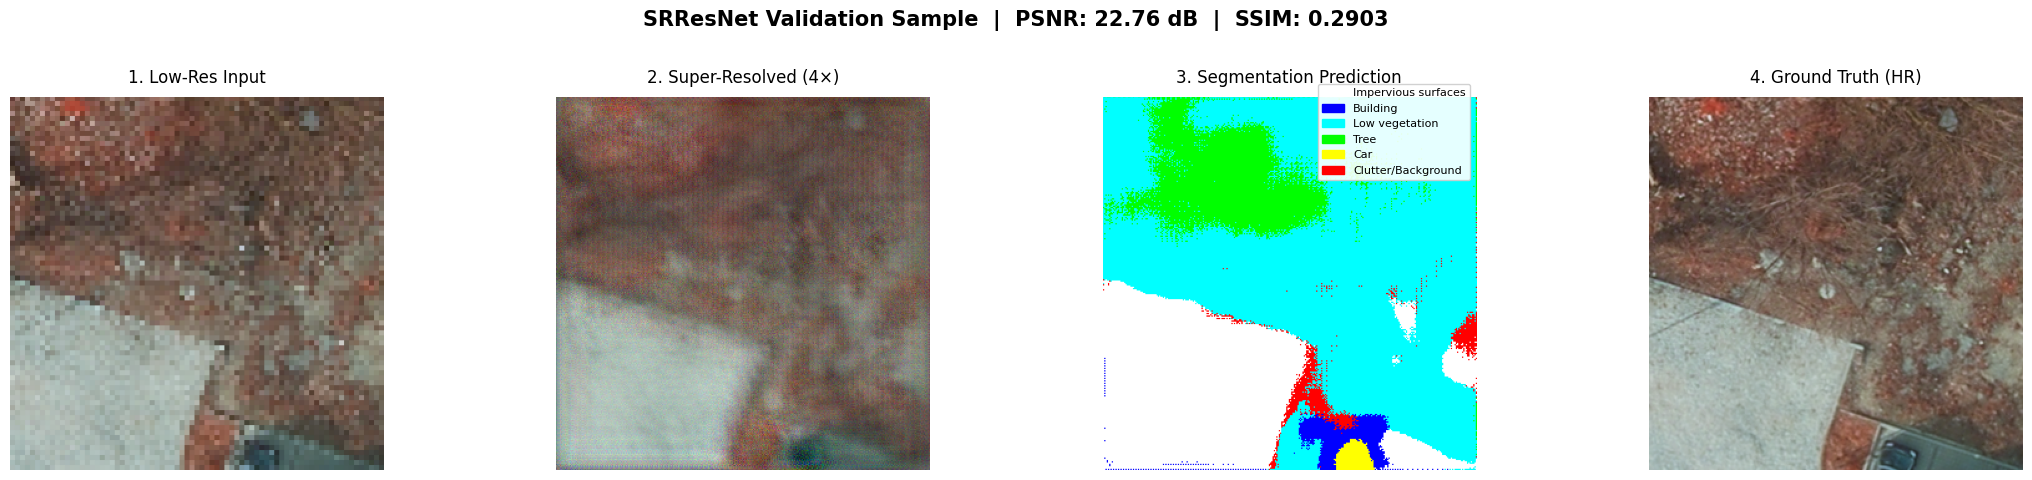

Running inference on 240 test images...


Test inference:   0%|          | 0/240 [00:00<?, ?it/s]

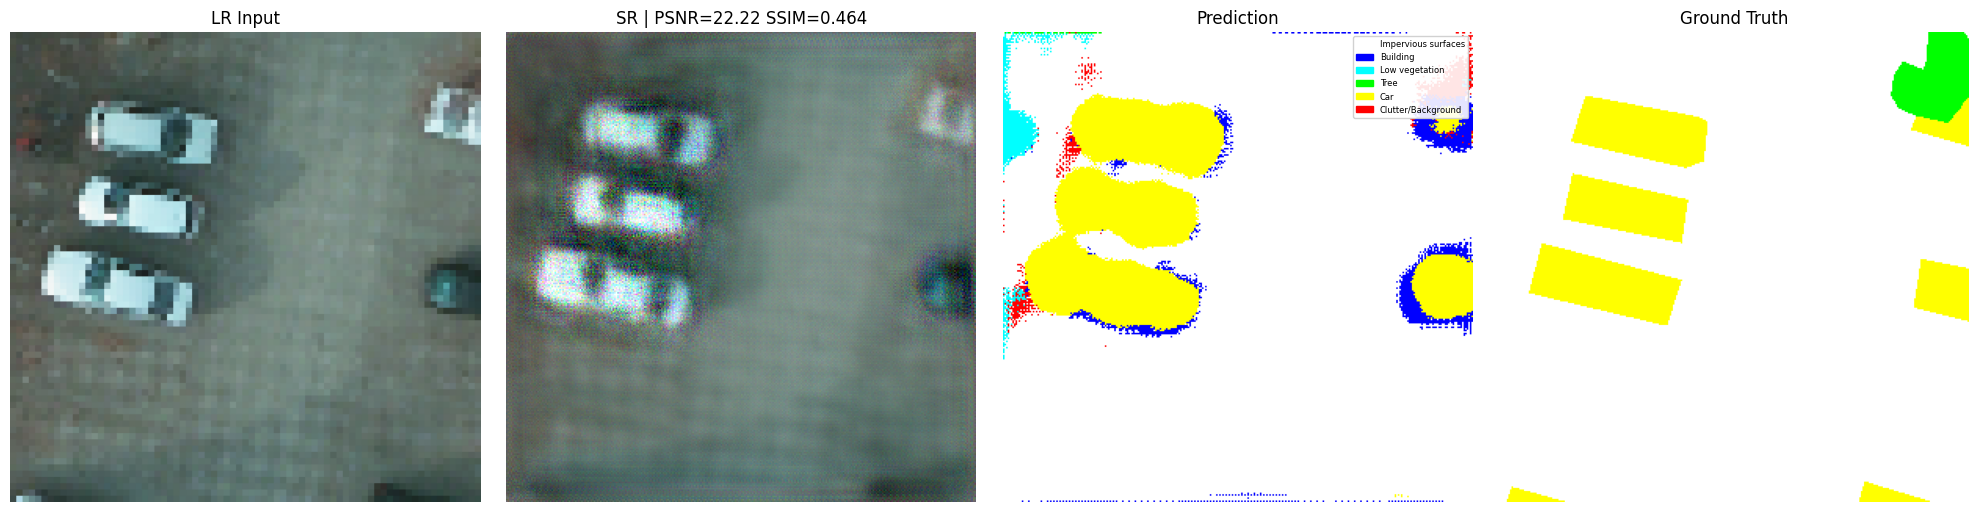

Test inference:   0%|          | 1/240 [00:00<01:41,  2.36it/s]

Saved: test_outputs\sample_0.png


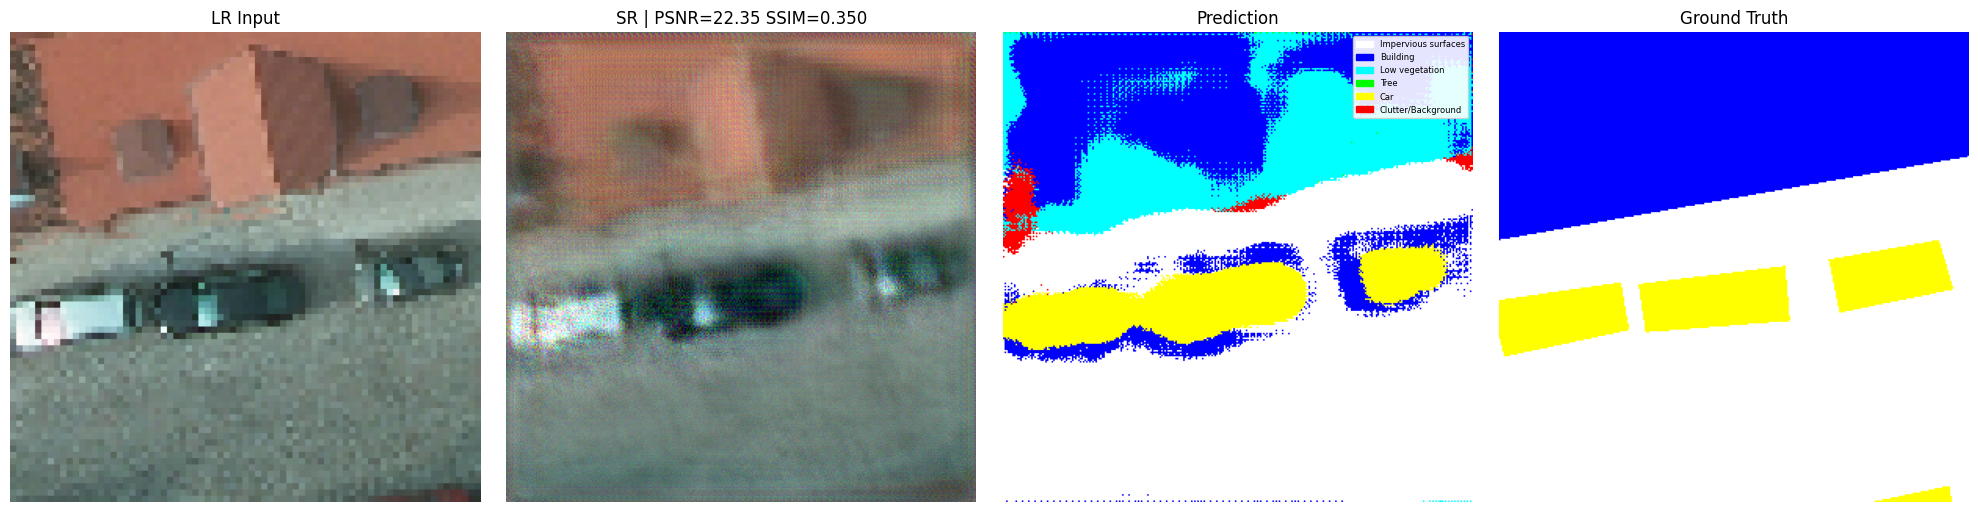

Test inference:   1%|          | 2/240 [00:00<01:43,  2.31it/s]

Saved: test_outputs\sample_1.png


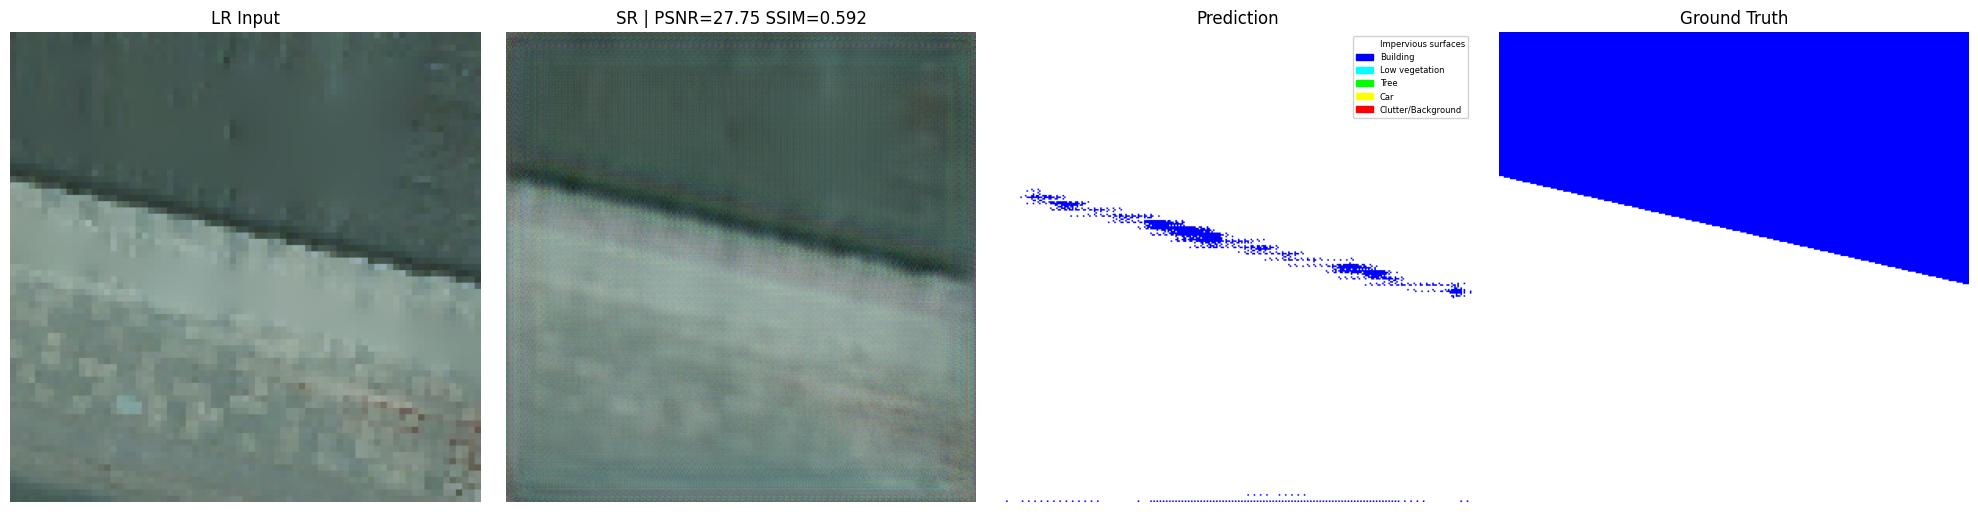

Test inference:   1%|▏         | 3/240 [00:01<01:41,  2.34it/s]

Saved: test_outputs\sample_2.png


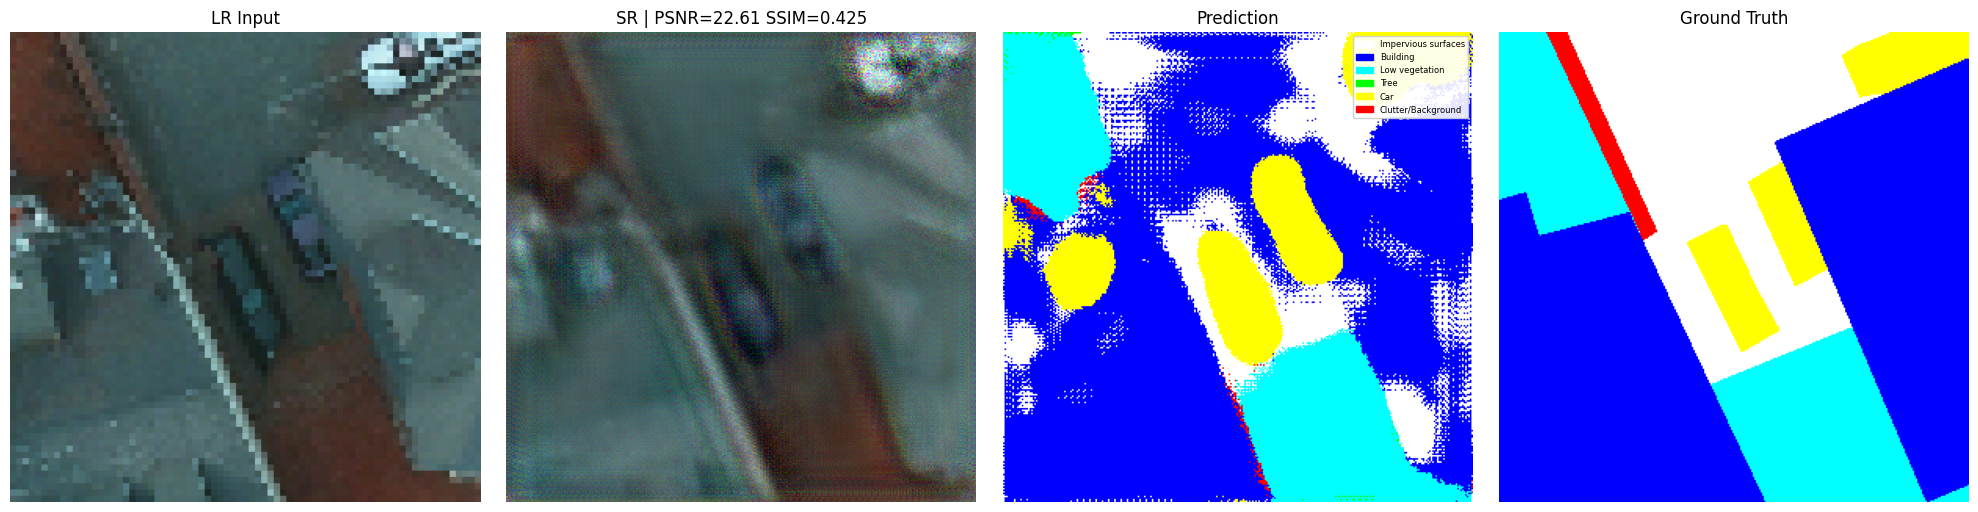

Test inference:   2%|▏         | 4/240 [00:01<01:42,  2.30it/s]

Saved: test_outputs\sample_3.png


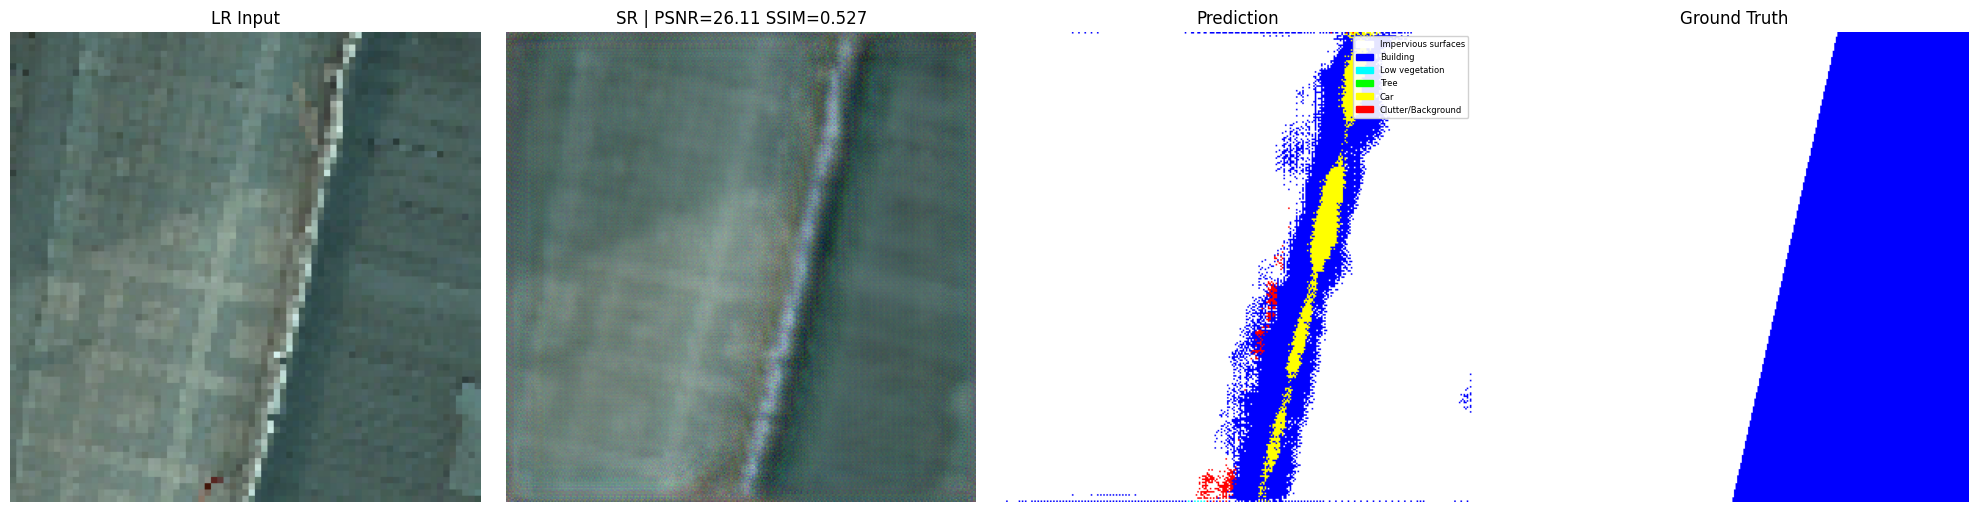

Test inference:   2%|▏         | 5/240 [00:02<01:51,  2.10it/s]

Saved: test_outputs\sample_4.png


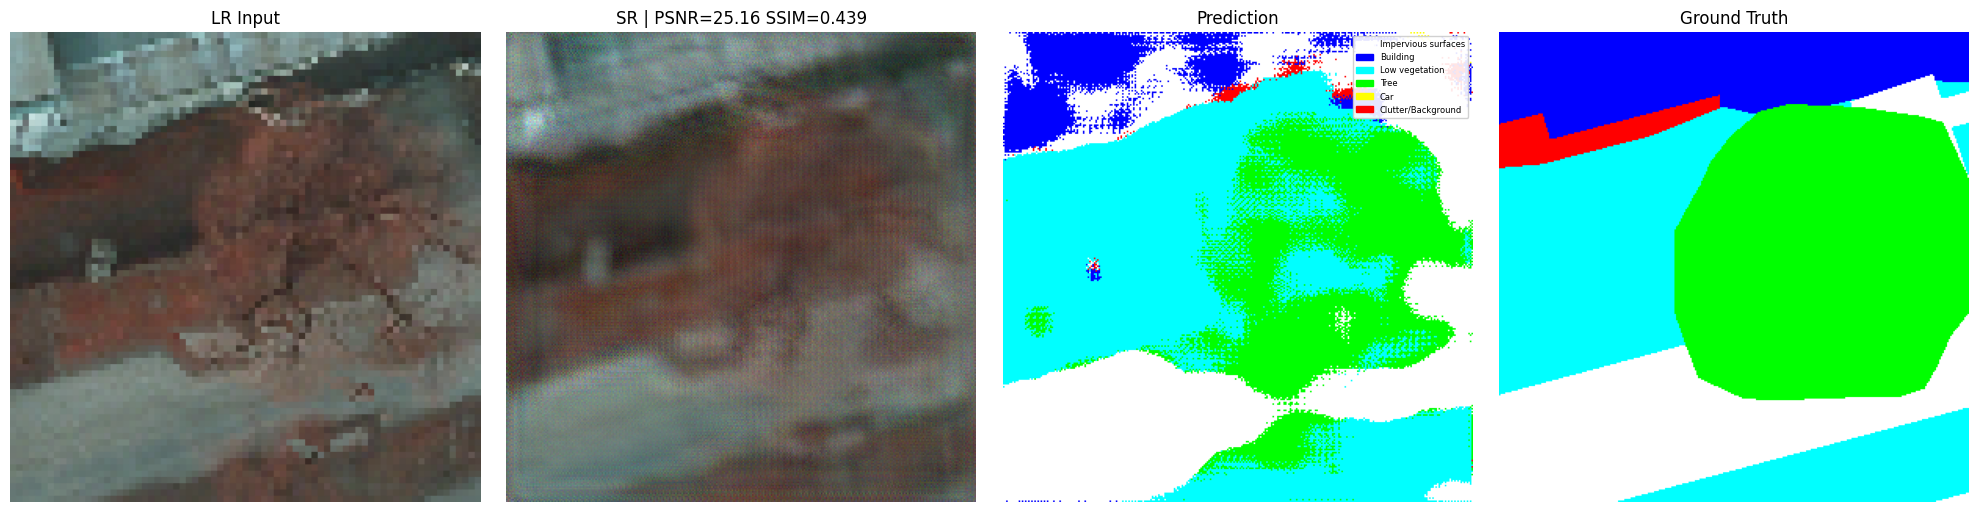

Test inference:   2%|▎         | 6/240 [00:02<01:48,  2.16it/s]

Saved: test_outputs\sample_5.png


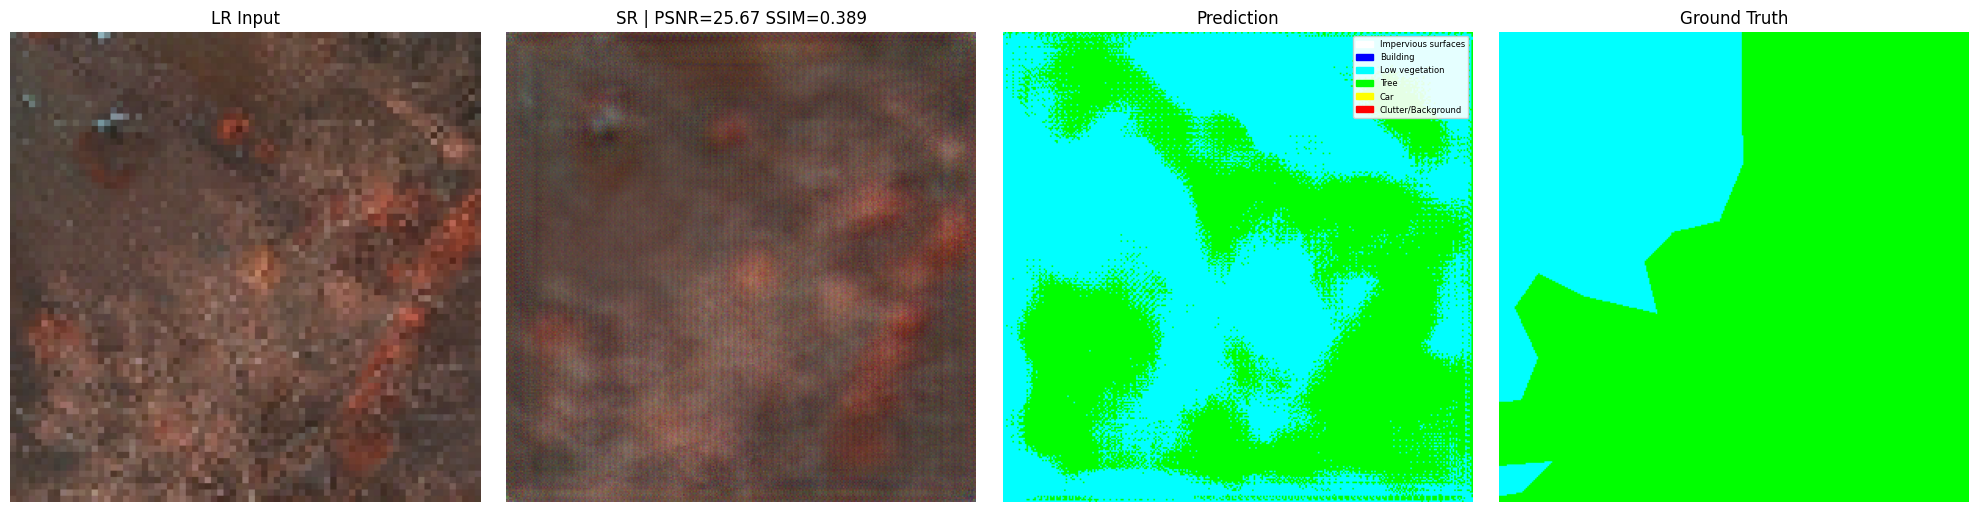

Test inference:   3%|▎         | 7/240 [00:03<01:45,  2.21it/s]

Saved: test_outputs\sample_6.png


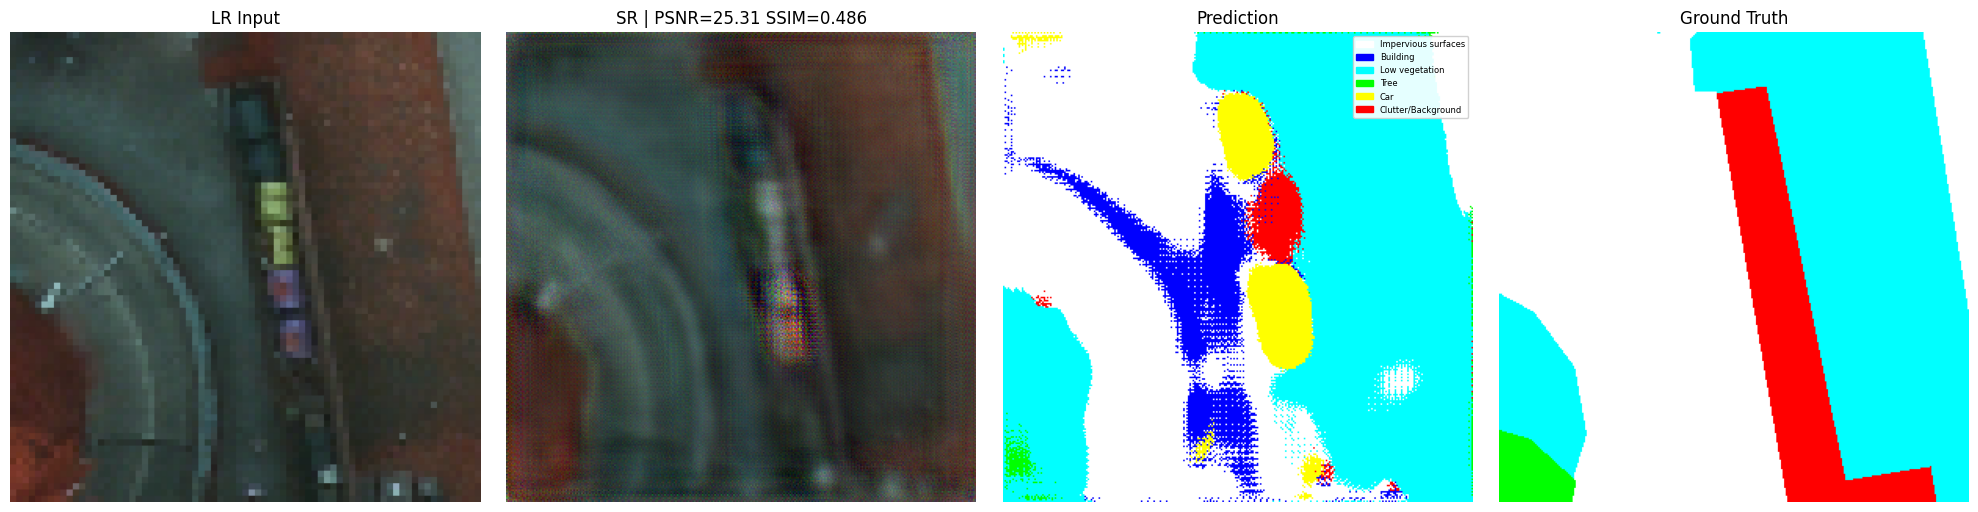

Test inference:   5%|▌         | 12/240 [00:03<00:40,  5.60it/s]

Saved: test_outputs\sample_7.png


Test inference: 100%|██████████| 240/240 [00:09<00:00, 24.68it/s]


DONE
Avg PSNR: 23.92
Avg SSIM: 0.4122


In [20]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model = model.to(DEVICE)

val_loader = DataLoader(get_val_dataset(), batch_size=1, shuffle=False)
test_loader = DataLoader(get_test_dataset(), batch_size=1, shuffle=False)

evaluate(model, val_loader)

visualize_sample(model, val_loader)

run_test_inference(model, save_dir="test_outputs", n_vis=8)